In [1]:
pip install yfinance pandas matplotlib

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.6 MB/s eta 0:00:01
   ------------------ --------------------- 0.8/1.7 MB 1.5 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.7 MB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 1.4 MB/s  0:00:01

   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   -- -------------------------------------  1/19 [peewee]
   -- -------------------------------------  1/19 [peewee]
   -- -------------------------------------  1/19 [peewee]
   -- ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import yfinance as yf
import pandas as pd

# 1. 设定股票池（涵盖科技、金融、能源、消费等）
tickers = ['AAPL', 'MSFT', 'TSLA', 'JPM', 'XOM', 'WMT', 'KO', 'NVDA', 'MCD', 'DIS']

# 2. 下载过去几年的每日数据
print("正在从雅虎财经下载数据，请稍候...")
data = yf.download(tickers, start="2019-12-01", end="2023-12-31")['Close']

# 3. 处理可能缺失的数据
data = data.ffill()

# 3. 展示下载好的数据格式
print("\n数据下载清洗完成！看看前5行的样子：")
display(data.head())

正在从雅虎财经下载数据，请稍候...


[*********************100%***********************]  10 of 10 completed


数据下载清洗完成！看看前5行的样子：


Ticker,AAPL,DIS,JPM,KO,MCD,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-12-02,63.618172,146.278183,110.355354,44.408226,167.800095,141.365356,5.201641,22.324667,36.231178,51.095001
2019-12-03,62.483860,144.296997,108.936760,44.449535,166.029129,141.138519,5.162117,22.413334,36.045898,50.691738
2019-12-04,63.035347,144.005646,111.085602,44.854374,167.052170,141.648972,5.205869,22.202000,36.051971,51.266773
2019-12-05,63.960136,143.189880,111.689987,44.771744,166.966232,141.724579,5.188964,22.024668,36.204529,51.087540
2019-12-06,65.195610,143.403534,113.351982,44.961777,167.946259,143.445023,5.274230,22.392668,36.546249,51.909008


In [ ]:
# 1. 计算动量因子：过去 20 个交易日的收益率
#  (今天价格 - 20天前价格) / 20天前价格
momentum_factor = data.pct_change(periods=20)

# 2. 清洗数据
momentum_factor = momentum_factor.dropna()

# 3. 查看我们的因子得分表
print("动量因子得分计算完成！正数代表过去20天上涨，负数代表下跌：")
display(momentum_factor.head())

动量因子得分计算完成！正数代表过去20天上涨，负数代表下跌：


Ticker,AAPL,DIS,JPM,KO,MCD,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-12-31,0.111637,-0.034016,0.060318,0.029767,0.012451,0.054497,0.124492,0.249231,0.000780,0.019877
2020-01-02,0.157641,0.003419,0.087147,0.022119,0.039716,0.075748,0.155302,0.279774,0.006771,0.044490
2020-01-03,0.136356,-0.006085,0.052049,0.007368,0.029695,0.058525,0.127256,0.330241,-0.002285,0.024472
2020-01-06,0.128850,-0.006222,0.045524,0.008858,0.041810,0.060695,0.135671,0.366771,-0.008512,0.035959
2020-01-07,0.102250,-0.007362,0.012680,-0.003124,0.037267,0.038418,0.130839,0.396469,-0.026883,0.011221


In [ ]:
# 1. 给每天的股票按动量得分排个名（得分最高的排第 1）
# axis=1 表示在同一天内跨股票横向比较，ascending=False 表示分数越高排名越靠前
rankings = momentum_factor.rank(axis=1, ascending=False)

# 2. 生成买入信号（买入排名前 3 的股票）
# 如果排名 <= 3，就标记为 1/3（代表占用三分之一的资金），否则标记为 0（不买）
positions = (rankings <= 3).astype(float) / 3

# 3. 计算股票每天真实的涨跌幅（为了算我们持仓到底赚没赚）
daily_returns = data.pct_change()

# 4. 用昨天的选股决定，乘以今天的实际涨跌幅，最后把三只股票的收益加起来 (sum)
strategy_returns = (positions.shift(1) * daily_returns).sum(axis=1)

# 清洗掉最开始没有仓位的空数据
strategy_returns = strategy_returns.dropna()

print("跳过12月预热期，策略正式满仓运行后的前5天收益：")
display(real_returns.head())

跳过12月预热期，策略正式满仓运行后的前5天收益：


Date
2020-01-02    0.023642
2020-01-03    0.001302
2020-01-06    0.010472
2020-01-07    0.015401
2020-01-08    0.022389
dtype: float64

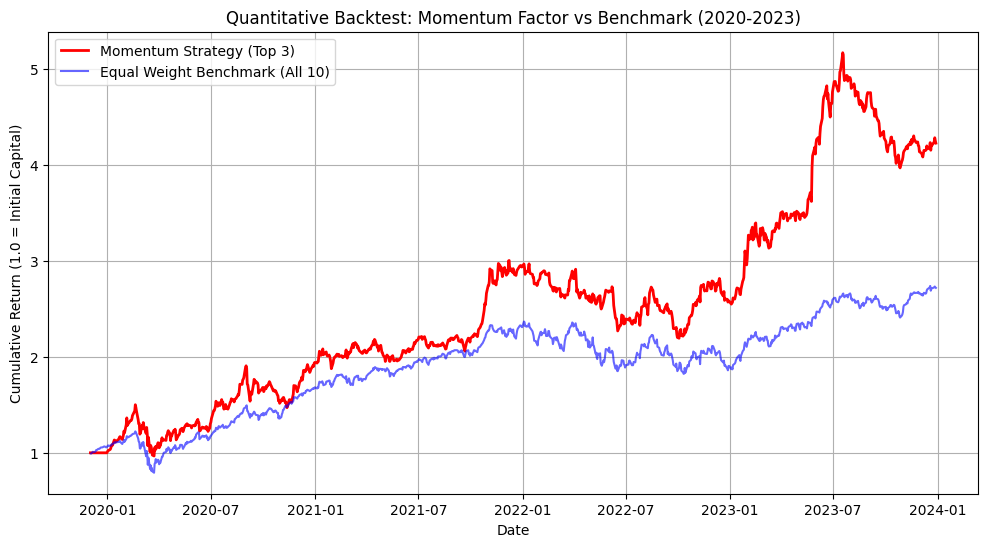

【最终成绩单】
如果用动量策略，你的 1 块钱变成了: 4.23 块
如果傻瓜式平均买，你的 1 块钱变成了: 2.72 块


In [ ]:
import matplotlib.pyplot as plt

# 1. 计算策略的“累计净值”（复利滚雪球）
strategy_cumulative = (1 + strategy_returns).cumprod()

# 2. 计算一个“基准线”作为对比
benchmark_returns = daily_returns.mean(axis=1) 
benchmark_cumulative = (1 + benchmark_returns).cumprod()

# 3. 开始画图！
plt.figure(figsize=(12, 6))

# 画出动量策略（红色粗线）
plt.plot(strategy_cumulative, label='Momentum Strategy (Top 3)', color='red', linewidth=2)

# 画出傻瓜基准线（蓝色细线）
plt.plot(benchmark_cumulative, label='Equal Weight Benchmark (All 10)', color='blue', alpha=0.6)

# 图表装饰
plt.title('Quantitative Backtest: Momentum Factor vs Benchmark (2020-2023)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = Initial Capital)')
plt.legend()
plt.grid(True)
plt.show()

# 4. 打印最终成绩单
print(f"【最终成绩单】")
print(f"如果用动量策略，你的 1 块钱变成了: {strategy_cumulative.iloc[-1]:.2f} 块")
print(f"如果傻瓜式平均买，你的 1 块钱变成了: {benchmark_cumulative.iloc[-1]:.2f} 块")

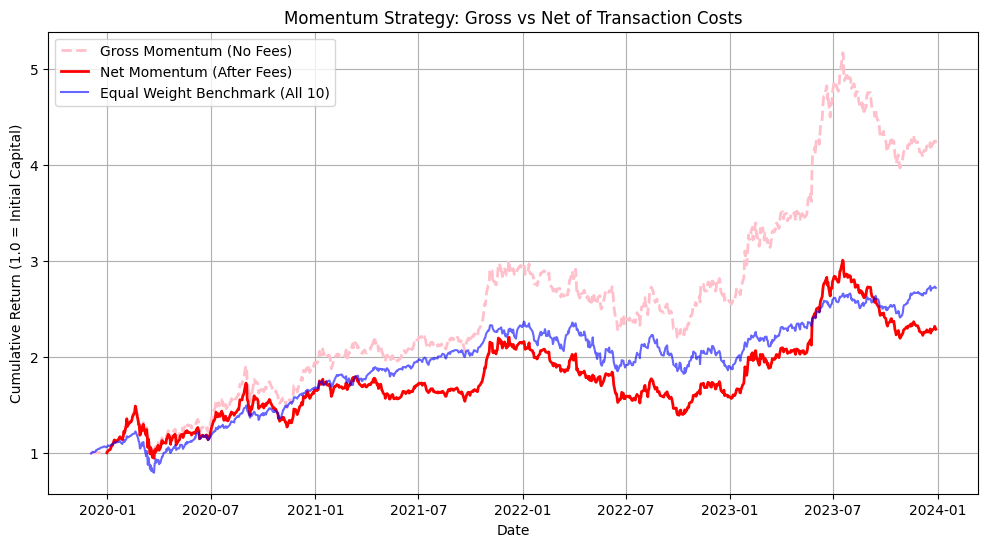

【真实战场成绩单】
不扣费的理想情况下，你的 1 块钱变成了: 4.23 块
扣除交易成本后，你的 1 块钱真实变成了: 2.29 块
傻瓜式平均买，你的 1 块钱变成了: 2.72 块


In [ ]:
import matplotlib.pyplot as plt

# 1. 设定单边交易成本（包含券商佣金和买卖滑点，假设为千分之二）
cost_rate = 0.002

# 2. 计算每天的“换仓比例”（Turnover）
turnover = positions.shift(1).diff().abs().sum(axis=1)

# 3. 计算扣除手续费后的“净收益”（Net Returns）
net_strategy_returns = strategy_returns - (turnover * cost_rate)

# 清理可能产生的空值
net_strategy_returns = net_strategy_returns.dropna()

# 4. 重新计算累计净值（滚雪球）
net_strategy_cumulative = (1 + net_strategy_returns).cumprod()

# 重新提取原本的理想收益和基准收益
strategy_cumulative = (1 + strategy_returns).cumprod() 
benchmark_cumulative = (1 + daily_returns.mean(axis=1).dropna()).cumprod()

# 5. 画图对比！
plt.figure(figsize=(12, 6))

# 不扣费的理想情况（粉色虚线，看看我们曾经有多天真）
plt.plot(strategy_cumulative, label='Gross Momentum (No Fees)', color='pink', linestyle='--', linewidth=2)

# 扣除手续费后的真实情况
plt.plot(net_strategy_cumulative, label='Net Momentum (After Fees)', color='red', linewidth=2)

# 傻瓜基准线（蓝色细线）
plt.plot(benchmark_cumulative, label='Equal Weight Benchmark (All 10)', color='blue', alpha=0.6)

# 图表装饰
plt.title('Momentum Strategy: Gross vs Net of Transaction Costs')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = Initial Capital)')
plt.legend()
plt.grid(True)
plt.show()

print(f"【真实战场成绩单】")
print(f"不扣费的理想情况下，你的 1 块钱变成了: {strategy_cumulative.iloc[-1]:.2f} 块")
print(f"扣除交易成本后，你的 1 块钱真实变成了: {net_strategy_cumulative.iloc[-1]:.2f} 块")
print(f"傻瓜式平均买，你的 1 块钱变成了: {benchmark_cumulative.iloc[-1]:.2f} 块")

In [ ]:
import numpy as np

# 1. 计算夏普比率 (假设无风险利率为 0)
sharpe_ratio = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)
bench_sharpe = (benchmark_returns.mean() / benchmark_returns.std()) * np.sqrt(252)

# 2. 计算最大回撤 (Max Drawdown)
# 动量策略的回撤
rolling_max = strategy_cumulative.cummax() # 计算截止到每天的历史最高净值
drawdowns = strategy_cumulative / rolling_max - 1.0 # 计算每天距离最高点跌了多少
max_drawdown = drawdowns.min() # 找出跌得最惨的那个极值

# 基准大盘的回撤
bench_rolling_max = benchmark_cumulative.cummax()
bench_drawdowns = benchmark_cumulative / bench_rolling_max - 1.0
bench_max_drawdown = bench_drawdowns.min()

# 3. 打印风险体检报告
print("【专业风控体检报告】")
print("=" * 40)
print("指标 1: 夏普比率 (性价比，越大越好)")
print(f"  ▶ 动量策略 Sharpe: {sharpe_ratio:.2f}")
print(f"  ▶ 基准大盘 Sharpe: {bench_sharpe:.2f}")
print("-" * 40)
print("指标 2: 最大回撤 (心脏承受力，越小越好)")
print(f"  ▶ 动量策略最惨跌幅: {max_drawdown * 100:.2f}%")
print(f"  ▶ 基准大盘最惨跌幅: {bench_max_drawdown * 100:.2f}%")
print("=" * 40)

【专业风控体检报告】
指标 1: 夏普比率 (性价比，越大越好)
  ▶ 动量策略 Sharpe: 1.27
  ▶ 基准大盘 Sharpe: 1.10
----------------------------------------
指标 2: 最大回撤 (心脏承受力，越小越好)
  ▶ 动量策略最惨跌幅: -35.57%
  ▶ 基准大盘最惨跌幅: -35.19%


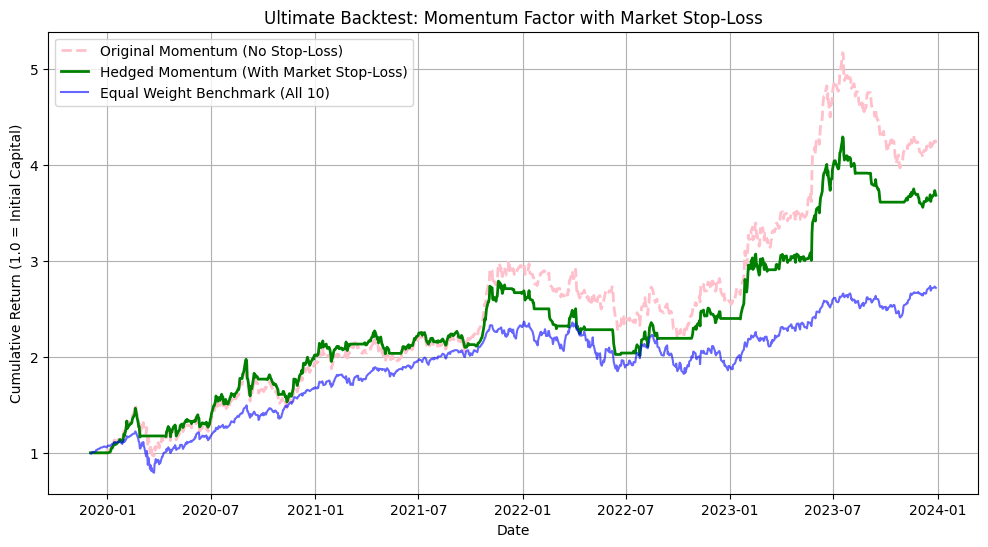

【终极防御系统体检报告】
▶ 原策略最惨跌幅: -35.57%
▶ 加上大盘止损后最惨跌幅: -27.86% 
----------------------------------------
▶ 最终你的 1 块钱安全变成了: 3.68 块


In [ ]:
import matplotlib.pyplot as plt

# 1. 构造“大盘指数”的历史真实走势（这 10 只股票每天的平均表现连起来）
benchmark_index = (1 + daily_returns.mean(axis=1)).cumprod()

# 2. 计算大盘的 20 天趋势（判断牛熊天气）
market_trend = benchmark_index.pct_change(20)

# 3. 生成“红绿灯信号” 
# 如果 trend > 0 返回 True (在数学运算中等于 1，绿灯)
# 如果 trend <= 0 返回 False (在数学运算中等于 0，红灯)
market_signal = (market_trend > 0).astype(int)

# 4. 把大盘信号融合进原策略仓位里
# 用我们挑好的 3 只股票仓位，去乘以大盘红绿灯（注意也要 shift(1) 避免未来函数）
# 只要亮红灯（0），无论你想买啥，仓位瞬间全部变成 0！
hedged_positions = positions.multiply(market_signal.shift(1), axis=0)

# 5. 重新计算带止损策略的真实收益
hedged_returns = (hedged_positions.shift(1) * daily_returns).sum(axis=1)
hedged_returns = hedged_returns.dropna()
hedged_cumulative = (1 + hedged_returns).cumprod()

# 6. 重新计算这套安全系统的最大回撤
hedged_rolling_max = hedged_cumulative.cummax()
hedged_drawdown = hedged_cumulative / hedged_rolling_max - 1.0
hedged_max_dd = hedged_drawdown.min()

# 7. 见证奇迹：画出终极对比图
plt.figure(figsize=(12, 6))

# 原本裸奔的动量策略（危险的粉色虚线）
plt.plot(strategy_cumulative, label='Original Momentum (No Stop-Loss)', color='pink', linestyle='--', linewidth=2)

# 装上大盘止损后的动量策略（安全的绿色粗线）
plt.plot(hedged_cumulative, label='Hedged Momentum (With Market Stop-Loss)', color='green', linewidth=2)

# 傻瓜基准线（蓝色细线）
plt.plot(benchmark_index, label='Equal Weight Benchmark (All 10)', color='blue', alpha=0.6)

plt.title('Ultimate Backtest: Momentum Factor with Market Stop-Loss')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = Initial Capital)')
plt.legend()
plt.grid(True)
plt.show()

# 8. 打印终极体检报告
print("【终极防御系统体检报告】")
print("=" * 40)
print(f"▶ 原策略最惨跌幅: {max_drawdown * 100:.2f}%")
print(f"▶ 加上大盘止损后最惨跌幅: {hedged_max_dd * 100:.2f}% ")
print("-" * 40)
print(f"▶ 最终你的 1 块钱安全变成了: {hedged_cumulative.iloc[-1]:.2f} 块")
print("=" * 40)